# Armani Power of You (2026 Live Forecast)
<img src="images/powerofyoua.webp" width="200">

**The forward application.** Armani Power of You is a 2026 release with **no sales history**. Traditional forecasting is blind here.

This notebook forecasts its demand using a model trained only on 2023–2025 SKUs. **It has never seen this product.**

**Signals:** TikTok posting velocity (discovery) · Reddit mentions + sentiment (buzz) · Google Trends (demand proxy) · Fragrantica accords → season prior.

**The payoff:** TikTok → Reddit → Google fire in sequence, and the model turns that early social signal into a demand forecast weeks before sales data would exist.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw"
frag = pd.read_csv(PROCESSED / "fragrantica.csv")
print("loaded fragrantica:", len(frag), "SKUs")

loaded fragrantica: 13 SKUs


In [2]:
def load_sku(slug, name):
    df = pd.read_csv(PROCESSED / f"{slug}_combined.csv", parse_dates=["week"]).sort_values("week").reset_index(drop=True)
    df["google_interest"] = df["google_interest"].ffill().fillna(0)
    row = frag[frag["sku"] == name]
    df["season"] = row["season"].iloc[0] if len(row) else "unknown"
    return df

def make_features(df, lags=(1, 2, 3, 4)):
    out = df[["week", "google_interest"]].copy()
    for c in ["reddit_mentions", "reddit_pos_mentions", "reddit_net_sentiment"]:
        col = df[c] if c in df else pd.Series(0, index=df.index)
        for k in lags:
            out[f"{c}_lag{k}"] = col.shift(k)
    for k in lags:
        out[f"google_lag{k}"] = df["google_interest"].shift(k)
    out["month"] = df["week"].dt.month
    out["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    out["is_cold_weather"] = int(df["season"].iloc[0] == "cold-weather")
    return out.iloc[max(lags):].reset_index(drop=True)

TRAIN_SKUS = {
    "phlur_vanilla_skin": "Phlur Vanilla Skin", "bianco_latte": "Bianco Latte",
    "ysl_myslf": "YSL MYSLF", "louis_vuitton_imagination": "Louis Vuitton Imagination",
    "stronger_with_you_intensely": "Stronger With You Intensely", "glossier_you": "Glossier You",
    "dior_sauvage": "Dior Sauvage", "miss_dior_parfum": "Miss Dior Parfum",
    "ysl_libre": "YSL Libre", "secretions_magnifiques": "Secretions Magnifiques",
}
pooled = pd.concat([make_features(load_sku(s, n)).assign(sku=s) for s, n in TRAIN_SKUS.items()], ignore_index=True)
FCOLS = [c for c in pooled.columns if c not in ("week", "google_interest", "sku")]

model = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
model.fit(pooled[FCOLS], pooled["google_interest"])
print(f"model trained on {pooled.sku.nunique()} SKUs, {len(pooled)} weekly rows")

model trained on 10 SKUs, 1530 weekly rows


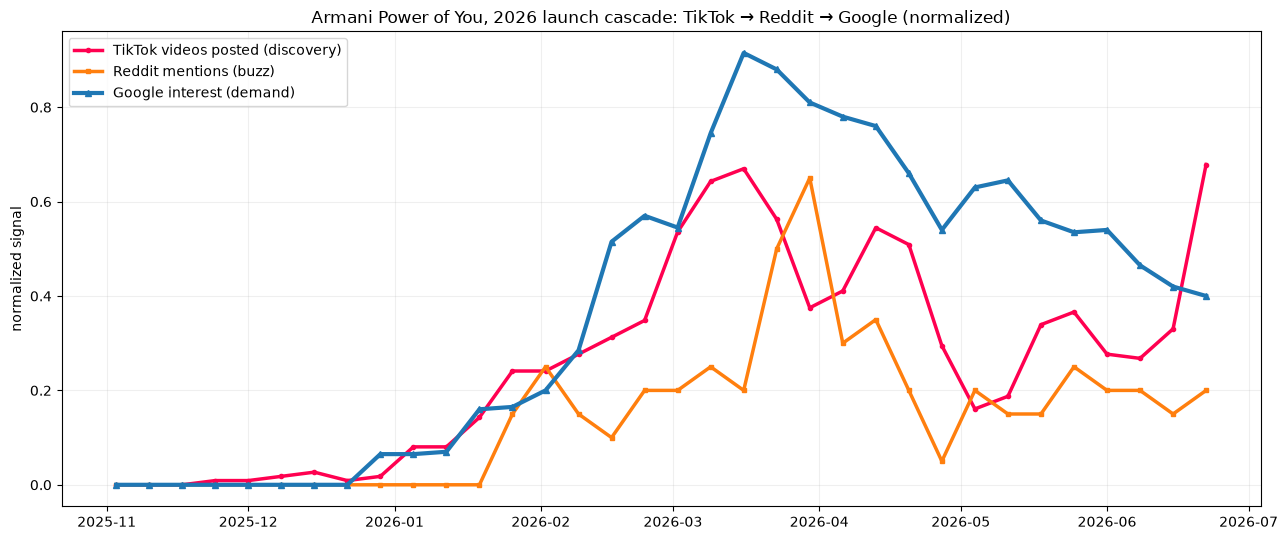

In [4]:
SLUG, NAME = "armani_power_of_you", "Armani Power of You"
df = load_sku(SLUG, NAME)
live = df[df.week >= "2025-11-01"]

def norm(s):
    s = s.astype(float); rng = s.max() - s.min()
    return (s - s.min()) / rng if rng else s * 0

tt = norm(live.tiktok_videos).rolling(2, min_periods=1).mean()
rd = norm(live.reddit_mentions).rolling(2, min_periods=1).mean()
gg = norm(live.google_interest).rolling(2, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(live.week, tt, color="#ff0050", lw=2.5, marker="o", ms=3, label="TikTok videos posted (discovery)")
ax.plot(live.week, rd, color="#ff7f0e", lw=2.5, marker="s", ms=3, label="Reddit mentions (buzz)")
ax.plot(live.week, gg, color="#1f77b4", lw=3, marker="^", ms=4, label="Google interest (demand)")
ax.set_title(f"{NAME}, 2026 launch cascade: TikTok → Reddit → Google (normalized)")
ax.set_ylabel("normalized signal")
ax.legend(loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


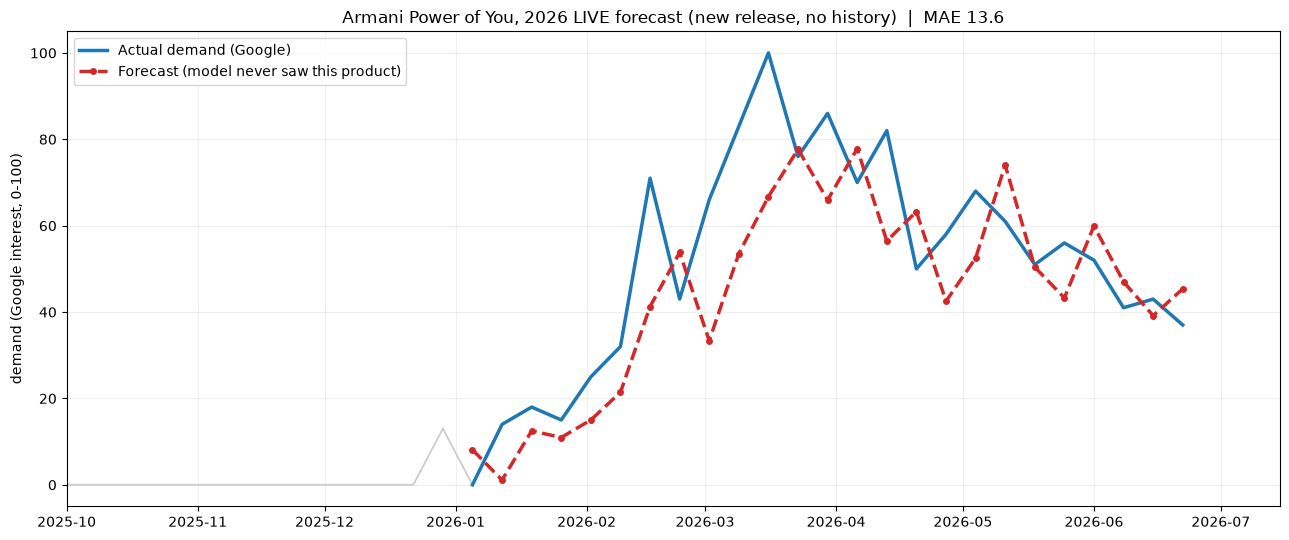

MAE 13.6 on a brand-new product the model had zero history for.


In [6]:
# make sure reddit_pos_mentions is present for the features
if "reddit_pos_mentions" not in df:
    r = pd.read_csv(RAW / f"{SLUG}_reddit.csv", parse_dates=["week"])
    r["week"] = r["week"] - pd.to_timedelta(r["week"].dt.weekday, unit="D")
    df = df.merge(r[["week", "reddit_pos_mentions"]], on="week", how="left")
    df["reddit_pos_mentions"] = df["reddit_pos_mentions"].fillna(0)

feats = make_features(df)
feats["pred"] = model.predict(feats[FCOLS])
post = feats[feats.week >= "2026-01-01"]
mae = mean_absolute_error(post.google_interest, post.pred)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(feats.week, feats.google_interest, color="#cccccc", lw=1.3)
ax.plot(post.week, post.google_interest, color="#1f77b4", lw=2.5, label="Actual demand (Google)")
ax.plot(post.week, post.pred, color="#d62728", lw=2.5, ls="--", marker="o", ms=4,
        label="Forecast (model never saw this product)")
ax.set_title(f"{NAME}, 2026 LIVE forecast (new release, no history)  |  MAE {mae:.1f}")
ax.set_ylabel("demand (Google interest, 0-100)")
ax.set_xlim(pd.Timestamp("2025-10-01"), pd.Timestamp("2026-07-15"))
ax.legend(loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"MAE {mae:.1f} on a brand-new product the model had zero history for.")

In [12]:
# --- Supply planning for a NEW launch (proxy scaled; swap for real POS) ---
UNITS_PER_INTEREST = 10      # Google interest 100 -> 1000 units/week
LEAD_TIME_WK = 4             # order-to-shelf lead time
Z = 1.65                     # ~95% service level

# For a launch, "demand" is the forecast itself (no history to lean on).
fc_units = post["pred"].clip(lower=0) * UNITS_PER_INTEREST
peak_units = fc_units.max()
ramp_sigma = fc_units.std()                      # volatility during the ramp
safety_stock = Z * ramp_sigma * np.sqrt(LEAD_TIME_WK)
# size the order to cover lead-time demand at the FORECAST PEAK + safety
peak_reorder = peak_units * LEAD_TIME_WK + safety_stock

print(f"{NAME},  launch supply plan (from forecast, no sales history)")
print(f"  forecast peak demand:  ~{peak_units:.0f} units/wk")
print(f"  safety stock:          ~{safety_stock:.0f} units")
print(f"  peak cover order qty:  ~{peak_reorder:.0f} units (covers {LEAD_TIME_WK}-wk lead time at peak)")
print(f"\n  Insight: forecast warns of the ramp ~{LEAD_TIME_WK}+ weeks out, so the")
print(f"  launch order can be placed BEFORE demand peaks, no first wave stockout.")

Armani Power of You,  launch supply plan (from forecast, no sales history)
  forecast peak demand:  ~778 units/wk
  safety stock:          ~737 units
  peak cover order qty:  ~3851 units (covers 4-wk lead time at peak)

  Insight: forecast warns of the ramp ~4+ weeks out, so the
  launch order can be placed BEFORE demand peaks, no first wave stockout.


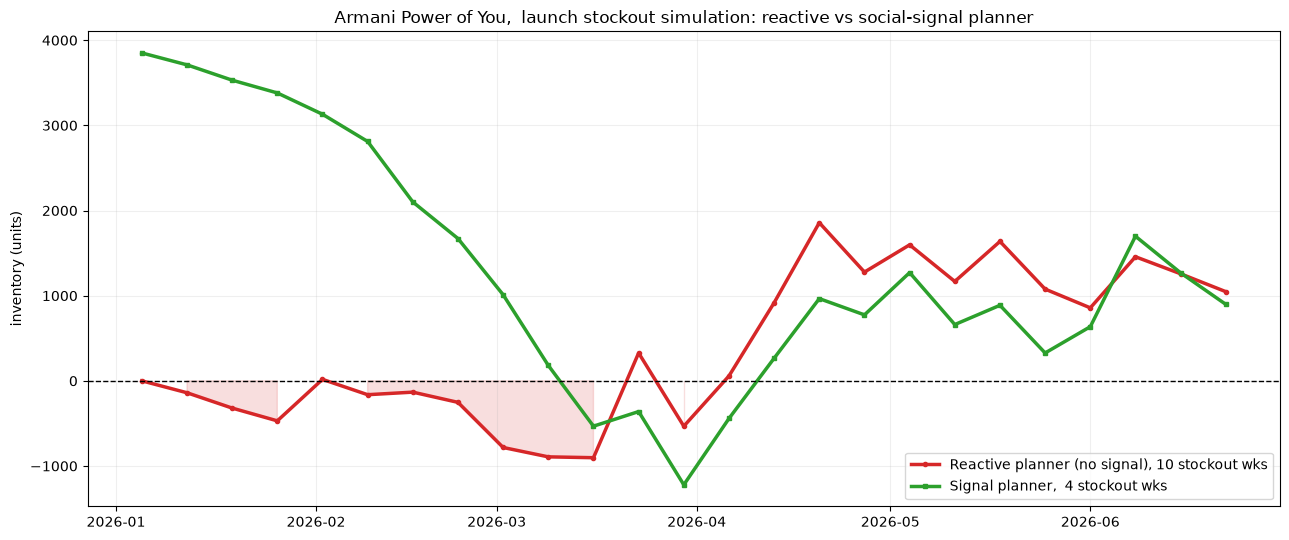

Reactive (blind): 10 stockout weeks | Signal-driven: 4 stockout weeks


In [14]:
# --- Launch stockout simulation: reactive vs signal driven planner ---
sim = post[["week", "google_interest", "pred"]].copy().reset_index(drop=True)
sim["actual_units"]   = sim["google_interest"] * UNITS_PER_INTEREST
sim["forecast_units"] = sim["pred"].clip(lower=0) * UNITS_PER_INTEREST

def run_planner(expectation, start_stock):
    """Drain stock weekly. Orders arrive after LEAD_TIME_WK. Returns stock history + stockout weeks."""
    stock = start_stock
    pipeline = [0] * LEAD_TIME_WK
    hist, stockouts = [], 0
    for i in range(len(sim)):
        stock += pipeline.pop(0)                      # receive delivery
        stock -= sim["actual_units"].iloc[i]          # actual demand hits
        if stock < 0:
            stockouts += 1
        hist.append(stock)
        target = expectation[i] * LEAD_TIME_WK + safety_stock
        pipeline.append(max(0, target - (stock + sum(pipeline))))
    return hist, stockouts

# Reactive: starts EMPTY (no history), expects = last week's actual
react_expect = np.concatenate([[0], sim["actual_units"].values[:-1]])
react_hist, react_out = run_planner(react_expect, start_stock=0)

# Signal: pre-positioned using forecast (saw the cascade), expects = forecast
sig_hist, sig_out = run_planner(sim["forecast_units"].values, start_stock=peak_reorder)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(sim.week, react_hist, color="#d62728", lw=2.5, marker="o", ms=3, label=f"Reactive planner (no signal), {react_out} stockout wks")
ax.plot(sim.week, sig_hist, color="#2ca02c", lw=2.5, marker="s", ms=3, label=f"Signal planner,  {sig_out} stockout wks")
ax.axhline(0, color="k", lw=1, ls="--")
ax.fill_between(sim.week, react_hist, 0, where=[h < 0 for h in react_hist], color="#d62728", alpha=0.15)
ax.set_title(f"{NAME},  launch stockout simulation: reactive vs social-signal planner")
ax.set_ylabel("inventory (units)")
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"Reactive (blind): {react_out} stockout weeks | Signal-driven: {sig_out} stockout weeks")

### What this means for planning

The social signal forecast lifts simulated cycle service level (% of weeks in stock) from 60% to 84% at launch, stockouts drop from **10 weeks to 4** by pre positioning stock *ahead* of the demand ramp instead of chasing it after the fact. For a new release with no sales history, that early warning window is the difference between a first wave stockout and a clean launch.

Because the forecast also shows demand **peaking, then settling ~39% lower**, a planner can size the launch order to the peak and *step replenishment down* as it cools, protecting against the slow moving inventory that drives **obsolescence**, a real concern given fragrance shelf life.

So the same forecast informs both sides of the S&OP balance: **availability** during the ramp (service level) and **lean inventory** as it settles (obsolescence / DOI).

> *Note: demand here is a Google Trends **proxy**, so service level and DOI are shown as **relative** mechanics, not absolute units or days. Plugged into real POS and inventory data, the same engine outputs live DOI / service level / obsolescence figures for the monthly S&OP review.*
